# Construcción de un espectro de respuesta usando el método de Newmark-beta

| Fecha | Autor | Correo | Descripción |
| ---  | --- | ---  | ---   |     
| 25 de agosto de 2026 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Código inicial creado usando Claude y Gemini 3.1 Pro |
| 31 de agosto de 2026 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Mejoras al código y a los comentarios, referencias al libro de Chapra |

En este cuaderno de Jupyter se explica paso a paso cómo calcular el espectro de respuesta para un sismo (en este caso, el sismo de El Centro de 1940) resolviendo la ecuación de movimiento diferencial para sistemas de un grado de libertad (1 GDL) utilizando el método numérico de integración de Newmark-beta.

## 1. Importación de bibliotecas y carga de datos

Primero, vamos a importar las bibliotecas necesarias para los cálculos matemáticos y la generación de gráficos. También cargaremos el registro del acelerograma. Asegúrese de que el archivo `elcentro_NS.dat` esté en el mismo directorio.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Configurar el backend de Matplotlib para usar widgets interactivos en Jupyter Notebook
%matplotlib widget

# DEFINICIONES DE PARÁMETROS BÁSICOS
Tmax = 3.0    # periodo máximo de análisis [s]
g    = 981.0  # aceleración de la gravedad [cm/s^2]
ZETA = 0.05   # razón de amortiguamiento: 5%

# LECTURA DEL ACELEROGRAMA
NOMBRE_SISMO  = "El Centro componente N-S"
ANIO_SISMO    = "1940"
ARCHIVO_SISMO = "elcentro_NS.dat"   # Archivo con los datos del sismo
dt            = 0.02                # paso de tiempo del registro [s]

# Carga de los datos
ag_g = np.loadtxt(ARCHIVO_SISMO)    # aceleración del suelo en fracción de [g]
ag = ag_g * g                       # aceleración del suelo en [cm/s^2]

# Creación del vector de tiempos
t_sismo = np.arange(len(ag)) * dt
tmax_sismo = t_sismo[-1]

print(f"Registro cargado: {len(ag)} puntos.")
print(f"Paso de tiempo dt = {dt} s.")
print(f"Duración total = {tmax_sismo:.2f} s.")
print(f"PGA (Peak Ground Acceleration) = {np.max(np.abs(ag_g)):.4f} g "
      f"({np.max(np.abs(ag)):.1f} cm/s^2)")

Registro cargado: 1560 puntos.
Paso de tiempo dt = 0.02 s.
Duración total = 31.18 s.
PGA (Peak Ground Acceleration) = 0.3188 g (312.8 cm/s^2)


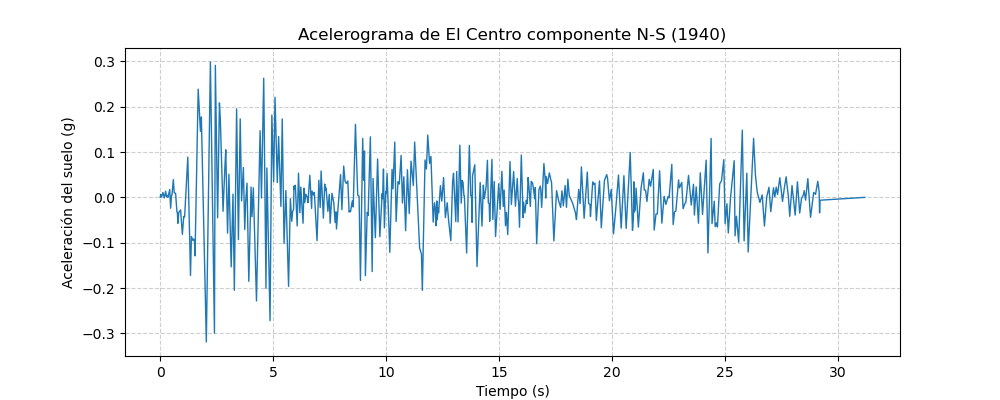

In [11]:
# Graficamos el acelerograma
plt.figure(figsize=(10, 4))
plt.plot(t_sismo, ag_g, lw=1)
plt.title
plt.title(f"Acelerograma de {NOMBRE_SISMO} ({ANIO_SISMO})")
plt.xlabel("Tiempo (s)")
plt.ylabel("Aceleración del suelo (g)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 2. El método de integración de Newmark-beta

El método de Newmark es una familia de métodos de integración en el tiempo paso a paso para resolver ecuaciones diferenciales de segundo orden, como la ecuación de movimiento de un oscilador de 1 GDL (Grado de Libertad):

$$ m\ddot{u} + c\dot{u} + ku = -m \ddot{u}_g(t) $$

Donde $u$ es el desplazamiento relativo, $m$ la masa, $c$ el amortiguamiento, $k$ la rigidez y $\ddot{u}_g(t)$ la aceleración del suelo.

Las ecuaciones fundamentales que definen el cambio en velocidad y desplazamiento durante el intervalo de tiempo $\Delta t = t_{i+1} - t_i$ son:

Para la velocidad:
$$ \dot{u}_{i+1} = \dot{u}_i + [(1 - \gamma)\Delta t]\ddot{u}_i + (\gamma \Delta t)\ddot{u}_{i+1} \tag{Chapra, eq. 5.4.1a}$$

Para el desplazamiento:
$$ u_{i+1} = u_i + (\Delta t)\dot{u}_i + [(0.5 - \beta)\Delta t^2]\ddot{u}_i + (\beta \Delta t^2)\ddot{u}_{i+1} \tag{Chapra, eq. 5.4.1b}$$

Los parámetros $\beta$ y $\gamma$ determinan cómo varía la aceleración dentro del del paso de tiempo y controlan la estabilidad y precisión del método. En ingeniería sísmica, la elección clásica de la "Aceleración Promedio Constante" implica usar $\gamma = 1/2$ y $\beta = 1/4$; de otro lado, el método de "Aceleración Lineal" usa $\gamma = 1/2$ y $\beta = 1/6$; este último método es más preciso pero menos estable que el primero.

Este esquema es **incondicionalmente estable**, lo que significa que el tamaño del paso temporal $\Delta t$ no causa inestabilidad numérica, aunque debe ser suficientemente pequeño para mantener una buena precisión.

### Formulación de la rigidez efectiva - Implementación numérica, de acuerdo con Chapra (2020, 5th ed.), Tabla 5.4.2.

Para poder programar este método sin tener que resolver un sistema de ecuaciones implícito en cada paso, las ecuaciones fundamentales referenciadas arriba se reorganizan y se sustituyen en la ecuación de movimiento original evaluada en el instante de tiempo $t_{i+1}$.

Esto transforma el problema de un paso dinámico a un equivalente estático de la forma:
$$
    \hat{k} u_{i+1} = \hat{p}_{i+1} \tag{Chapra, eq. 5.4.10}
$$

Las constantes de integración empleadas para agrupar los términos (`a1`, `a2`, `a3` en el código) se derivan algebraicamente y corresponden a:

$$ a_1 = \frac{m}{\beta \Delta t^2} + \frac{\gamma c}{\beta \Delta t} $$
$$ a_2 = \frac{m}{\beta \Delta t} + \left(\frac{\gamma}{\beta} - 1\right)c $$
$$ a_3 = \left(\frac{1}{2\beta} - 1\right)m + \Delta t\left(\frac{\gamma}{2\beta} - 1\right)c $$

Con estas constantes, definimos la **rigidez efectiva del paso** ($\hat{k}$, expresada como `k_hat` en el código):
$$ \hat{k} = k + a_1 \tag{Chapra, eq. 5.4.11}$$

Y en cada iteración del tiempo, determinamos el desplazamiento $u_{i+1}$ utilizando la fuerza externa en ese instante $p_{i+1} = -m\ddot{u}_g(t_{i+1})$ y el historial anterior del movimiento del oscilador acumulado en la carga efectiva
$$
\hat{p}_{i+1} = p_{i+1} + a_1 u_i + a_2 \dot{u}_i + a_3 \ddot{u}_i \tag{Chapra, eq. 5.4.12}$$
de modo que la ecuación de movimiento se reduce a una forma algebraica simple:
$$
u_{i+1} = \frac{\hat{p}_{i+1}}{\hat{k}} \tag{Chapra, eq. 5.4.13}
$$

Una vez despejamos explícitamente el desplazamiento $u_{i+1}$, las ecuaciones de velocidad y aceleración se actualizan directamente retro-sustituyendo:

Aceleración:
$$ \ddot{u}_{i+1} = \frac{1}{\beta \Delta t^2}(u_{i+1} - u_i) - \frac{1}{\beta \Delta t}\dot{u}_i - \left(\frac{1}{2\beta} - 1\right)\ddot{u}_i \tag{Chapra, eq. 5.4.8}
$$

Velocidad (derivada de la aceleración previa):
$$ \dot{u}_{i+1} = \frac{\gamma}{\beta \Delta t}(u_{i+1} - u_i) + \left(1 - \frac{\gamma}{\beta}\right)\dot{u}_i + \Delta t\left(1 - \frac{\gamma}{2\beta}\right)\ddot{u}_i 
\tag{Chapra, eq. 5.4.9}$$

EL método de Newmark-beta es estable si
$$
\frac{\Delta t}{T_n} < \frac{1}{\pi \sqrt{2}}\frac{1}{\gamma - 2 \beta} \tag{Chapra, eq. 5.4.15}
$$

A continuación, implementamos la función que usa estrictamente esta reformulación algebraica paso a paso.

In [12]:
def respuesta_1gdl_newmark(ag, dt, T, zeta, beta=1/4, gamma=1/2):
    """
    Resuelve la ecuación de movimiento de un oscilador de 1 GDL sometido
    a una aceleración de base ag(t), mediante el método de integración
    directa de Newmark-beta.

    Parámetros
    ----------
    ag    : array, aceleración del suelo
    dt    : paso de tiempo del registro [s]
    T     : periodo natural del oscilador [s]
    zeta  : razón de amortiguamiento crítico 

    Para el método de la aceleración promedio constante (Newmark-beta):
    beta  : 1/4
    gamma : 1/2
    Este método es incondicionalmente estable y es el más usado en ingeniería sísmica.

    Para el método de la aceleración lineal (Newmark-beta):
    beta  : 1/6
    gamma : 1/2
    Este método es más preciso pero menos estable que el anterior.

    Retorna
    -------
    u, v, a : desplazamiento, velocidad y aceleración RELATIVOS
    a_abs   : aceleración ABSOLUTA de la masa
    """

    # Verificar si la elección de gamma y beta es estable:    
    if gamma == 1/2 and beta == 1/4:
        # Método de aceleración promedio constante:
        # El lado derecho de la desigualdad de estabilidad se vuelve 
        # infinito, por lo que el método es incondicionalmente estable.
        pass  
    else:
        assert(dt/T < 1/(np.pi*np.sqrt(2)) * 1/(gamma - 2*beta)), \
            "El método de Newmark-beta no es estable para los parámetros dados."

    wn = 2*np.pi/T  # frecuencia natural [rad/s]
    m = 1.0         # masa unitaria (no afecta al espectro de aceleraciones o desplazamientos relativos)
    k = m*wn**2
    c = 2*zeta*m*wn

    n = len(ag)
    u = np.zeros(n)
    v = np.zeros(n)
    a = np.zeros(n)

    # Cálculo de la aceleración inicial usando equilibrio, Chapra eq. 5.4.14
    a[0] = (-m*ag[0] - c*v[0] - k*u[0])/m

    # Constantes de integración de Newmark para la formulación efectiva de rigidez
    a1 = m/(beta*dt**2) + gamma*c/(beta*dt)
    a2 = m/(beta*dt) + (gamma/beta - 1)*c
    a3 = (1/(2*beta) - 1)*m + dt*(gamma/(2*beta) - 1)*c
    
    # Rigidez efectiva
    k_hat = k + a1

    for i in range(n - 1):
        # Desplazamiento en t_i+1 (utilizando la carga efectiva)
        p_hat_ip1 = (-m*ag[i + 1]) + a1*u[i] + a2*v[i] + a3*a[i]
        u[i + 1] = p_hat_ip1/k_hat

        # Velocidad en t_i+1
        v[i + 1] = (gamma/(beta*dt))*(u[i + 1] - u[i]) + (1 - gamma/beta)*v[i] + dt*(1 - gamma/(2*beta))*a[i]

        # Aceleración en t_i+1
        a[i + 1] = (u[i + 1] - u[i])/(beta*dt**2) - v[i]/(beta*dt) - (1/(2*beta) - 1)*a[i]

    # Aceleración absoluta construida
    a_abs = a + ag
    
    return u, v, a, a_abs

## 3. El método de integración con `scipy.integrate.solve_ivp`

A modo comparativo, también vamos a definir una función que obtenga el historial de desplazamiento, velocidad y aceleración resolviendo la Ecuación Diferencial Ordinaria (ODE) usando las funciones de integración incluidas en el paquete científico de Python `scipy`, de modo que emplearemos el método `solve_ivp` (Initial Value Problem).

Al interior de esta función se usará la interpolación lineal para evaluar la aceleración del terreno $a_g(t)$ en cualquier sub-iteración que solicite el solver.

In [13]:
# SOLUCIÓN DE LA ECUACIÓN DE MOVIMIENTO (INTEGRANDO CON scipy.integrate.solve_ivp)
def respuesta_1gdl_solve_ivp(ag, dt, T, zeta):
    """
    Resuelve la ecuación de movimiento de un oscilador de 1 GDL sometido
    a una aceleración de base ag(t), mediante el método de integración
    directa de scipy.integrate.solve_ivp.

        m*u'' + c*u' + k*u = -m*ag(t)

    Parámetros
    ----------
    ag    : array, aceleración del suelo [cm/s^2]
    dt    : paso de tiempo del registro [s]
    T     : periodo natural del oscilador [s]
    zeta  : razón de amortiguamiento crítico (p.ej. 0.05 para 5%)

    Retorna
    -------
    u, v, a : desplazamiento, velocidad y aceleración RELATIVOS de la masa
    a_abs   : aceleración ABSOLUTA de la masa (a_abs'' = a_rel + ag),
              que es la cantidad físicamente registrada por un
              acelerómetro montado sobre la masa, y la que define el
              espectro de respuesta de aceleraciones Sa.
    """
    # Importamos el solver de ecuaciones diferenciales ordinarias
    from scipy.integrate import solve_ivp

    # Propiedades dinámicas del oscilador
    wn = 2*np.pi/T                     # frecuencia natural [rad/s]
    m = 1.0                            # masa unitaria (no afecta la respuesta normalizada)
    k = m*wn**2                        # rigidez estructural
    c = 2*zeta*m*wn                    # coeficiente de amortiguamiento

    # Definición de la ecuación de estado para el solver (sistema de 1er orden)
    def ecuacion_movimiento(t, y):
        # y contiene [desplazamiento, velocidad]
        u, v = y
        
        # Interpolación lineal para obtener la aceleración del terreno ag(t) 
        # en un instante de tiempo arbitrario 't' requerido por el solver
        idx = int(t/dt)
        if idx >= len(ag) - 1:
            ag_t = ag[-1]
        else:
            ag_t = ag[idx] + (ag[idx + 1] - ag[idx]) * ((t - idx*dt)/dt)
            
        # Las derivadas del estado
        du_dt = v
        # Despejamos la aceleración u'' de la ecuación de movimiento
        dv_dt = (-c*v - k*u - m*ag_t)/m
        
        return [du_dt, dv_dt]

    # Tiempo en los que queremos que el solver nos devuelva la solución
    t_sismo = np.arange(len(ag))*dt
    
    # Intervalo total de integración
    t_span = (t_sismo[0], t_sismo[-1])
    
    # Llamado al solver con condiciones iniciales de reposo [u=0, v=0]
    sol = solve_ivp(ecuacion_movimiento, t_span, [0, 0], t_eval=t_sismo)

    # Extraemos el historial de u(t) y v(t) resuelto
    u = sol.y[0]
    v = sol.y[1]
    
    # Solve_ivp no nos devuelve directamente la aceleración, 
    # por lo que debemos recuperarla a partir de u, v y el equilibrio
    a_rel = np.empty_like(u)
    for i, tiempo in enumerate(t_sismo):
        # Mismo procedimiento de interpolación para obtener ag(t)
        idx = min(int(tiempo/dt), len(ag) - 1)
        if idx == len(ag) - 1:
            ag_t = ag[-1]
        else:
            fraccion = (tiempo - idx*dt)/dt
            ag_t = ag[idx] + (ag[idx + 1] - ag[idx])*fraccion
            
        # Despejamos la aceleración relativa en cada instante
        a_rel[i] = (-c*v[i] - k*u[i] - m*ag_t)/m
        
    # Finalmente calculamos la aceleración absoluta sumando la aceleración del terreno
    a_abs = a_rel + ag                # aceleración absoluta de la masa

    return u, v, a_rel, a_abs

## 4. Obtención y graficación de las respuestas

En la siguiente celda de código, utilizamos las funciones `respuesta_1gdl_newmark` y `respuesta_1gdl_solve_ivp`. Evaluamos un oscilador de un grado de libertad con un periodo natural $T=0.5$ s y una razón de amortiguamiento del 5% ($\zeta=0.05$). 

El código toma el acelerograma previamente leído y calcula las respuestas con ambos métodos. **Adicionalmente, se mide el tiempo de ejecución** para comparar la eficiencia de ambos enfoques. 

Posteriormente, utilizamos `matplotlib` para generar un panel con tres gráficas que comparan los historiales de:
1. **Desplazamiento relativo** $u(t)$ en cm.
2. **Velocidad relativa** $\dot{u}(t)$ en cm/s.
3. **Aceleración absoluta** $\ddot{u}_{abs}(t)$ en cm/s².

Tiempo de ejecución de Newmark-Beta = 0.0047 s
Tiempo de ejecución de solve_ivp    = 0.0895 s
Newmark-Beta es ~19.2 veces más rápido.


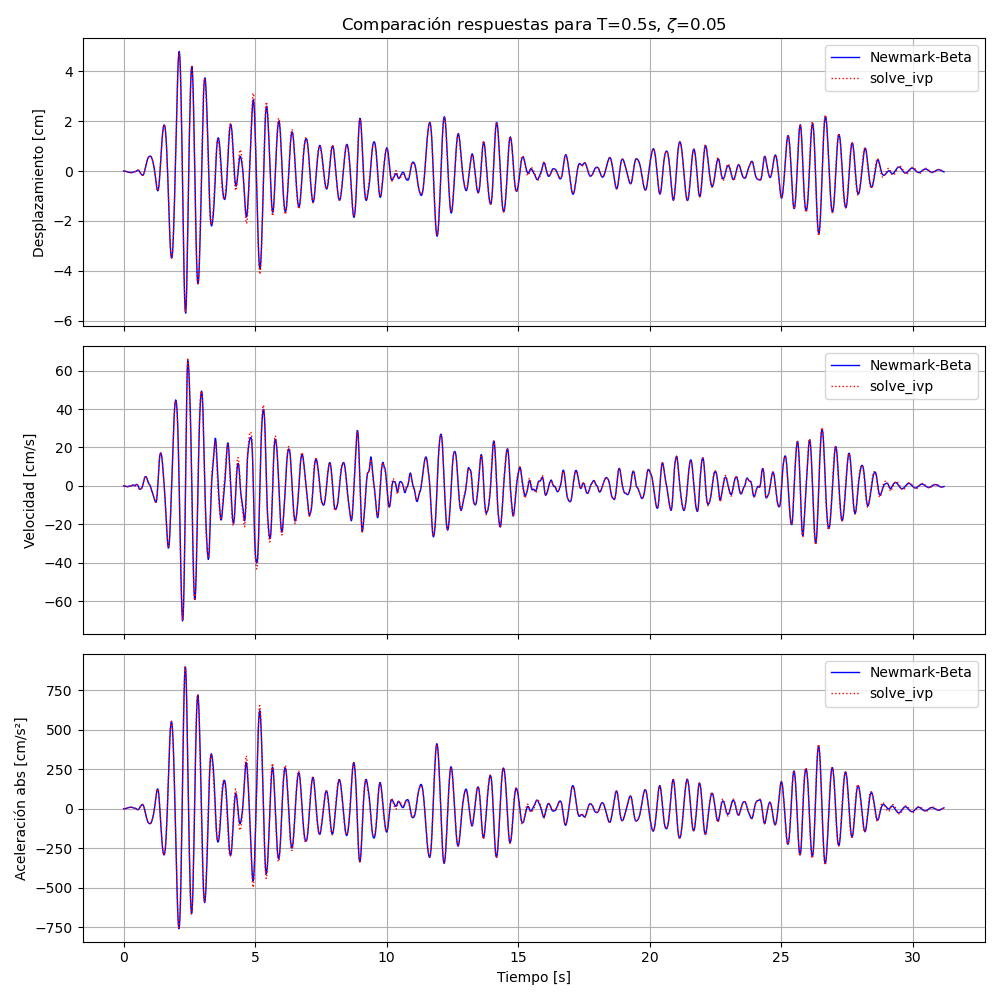

In [14]:
import time

T = 0.5    # seg
ZETA = 0.05

# Tiempo para Newmark-Beta
t_start = time.perf_counter()
u_nb,  v_nb,  a_rel_nb,  a_abs_nb  = respuesta_1gdl_newmark(ag, dt, T, ZETA)
t_nb = time.perf_counter() - t_start

# Tiempo para solve_ivp
t_start = time.perf_counter()
u_ivp, v_ivp, a_rel_ivp, a_abs_ivp = respuesta_1gdl_solve_ivp(ag, dt, T, ZETA)
t_ivp = time.perf_counter() - t_start

print(f"Tiempo de ejecución de Newmark-Beta = {t_nb:.4f} s")
print(f"Tiempo de ejecución de solve_ivp    = {t_ivp:.4f} s")
print(f"Newmark-Beta es ~{t_ivp/t_nb:.1f} veces más rápido.")

# Gráficos de las respuestas
fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Desplazamiento
axs[0].plot(t_sismo, u_nb,  'b',   label='Newmark-Beta', linewidth=1)
axs[0].plot(t_sismo, u_ivp, 'r:', label='solve_ivp',    linewidth=1)
axs[0].set_ylabel('Desplazamiento [cm]')
axs[0].grid(True)
axs[0].legend()
axs[0].set_title(f'Comparación respuestas para T={T}s, $\zeta$={ZETA}')

# Velocidad
axs[1].plot(t_sismo, v_nb,  'b',   label='Newmark-Beta', linewidth=1)
axs[1].plot(t_sismo, v_ivp, 'r:', label='solve_ivp',    linewidth=1)
axs[1].set_ylabel('Velocidad [cm/s]')
axs[1].grid(True)
axs[1].legend()

# Aceleración absoluta
axs[2].plot(t_sismo, a_abs_nb,  'b-',   label='Newmark-Beta', linewidth=1)
axs[2].plot(t_sismo, a_abs_ivp, 'r:', label='solve_ivp',    linewidth=1)
axs[2].set_ylabel('Aceleración abs [cm/s²]')
axs[2].set_xlabel('Tiempo [s]')
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.show()

Observe que existen algunas discrepancias entre los resultados de ambos métodos, especialmente en los picos de las respuestas, debido a la naturaleza de la integración numérica y la interpolación de los datos del acelerograma. Sin embargo, ambos métodos deberían producir resultados consistentes dentro de un margen aceptable de error. Como el método de Newmark-beta es más rápido que el método de integración de `solve_ivp`, suele ser preferido en aplicaciones de ingeniería sísmica donde se requiere evaluar múltiples periodos y amortiguamientos para construir un espectro de respuesta completo.

## 5. Cálculo de los espectros de respuesta

Para construir el espectro de respuesta, tomamos un amplio rango de periodos naturales $T$ (representando diferentes edificios teóricos) e iteramos:
1. Sometemos el oscilador de periodo $T$ al terremoto.
2. Recuperamos su máxima respuesta.

Las variables típicas del espectro son:

* **Espectro de Desplazamiento ($S_d$)**: 
$$ S_d(T) = \max_t | u(t) | $$
(Máximo desplazamiento relativo)

* **Espectro de Pseudo-Velocidad ($PS_v$)**:
$$ PS_v(T) = \omega \cdot S_d(T) = \frac{2\pi}{T} S_d(T) $$
(Aproximación de la velocidad máxima)

* **Espectro de Pseudo-Aceleración ($PS_a$)**: 
$$ PS_a(T) = \omega^2 \cdot S_d(T) = \left( \frac{2\pi}{T} \right)^2 S_d(T) $$
(Aproximación útil para aceleración absoluta y fuerza cortante en la base)

Para el **espectro de aceleración absoluta** $S_a$, tomaremos el máximo de la historia calculada `a_abs`:
$$ S_a(T) = \max_t | \ddot{u}_{abs}(t) | $$

In [15]:
# Definir array de periodos de T=0.01s a Tmax (3.0s o 4.0s)
periodos = np.arange(0.01, Tmax + 0.01, 0.01)

# Vectores para almacenar los espectros
Sd  = np.zeros_like(periodos)
Sv  = np.zeros_like(periodos)
Sa  = np.zeros_like(periodos)
PSv = np.zeros_like(periodos)
PSa = np.zeros_like(periodos)

# Bucle principal para extraer los valores máximos a cada periodo T
for i, T in enumerate(periodos):
    wn = 2*np.pi/T
    
    # Calcular respuesta usando la función de Newmark definida previamente
    u, v, a, a_abs = respuesta_1gdl_newmark(ag, dt, T, ZETA)
    
    # Extraer y calcular valores máximos para el espectro
    Sd[i] = np.max(np.abs(u))
    Sv[i] = np.max(np.abs(v))
    Sa[i] = np.max(np.abs(a_abs))
    
    # Pseudo-espectros
    PSv[i] =    wn * Sd[i]
    PSa[i] = wn*wn * Sd[i]

## 6. Visualización de los Espectros

En esta sección final generamos las gráficas estándar que típicamente se analizan tras un sismo. Representamos frente al periodo $T$:
* El Espectro de Desplazamiento ($S_d$)
* El Espectro Pseudo-Velocidad ($PS_v$)
* El Espectro Pseudo-Aceleración ($PS_a$) normalizado como fracción de la gravedad ($g$).

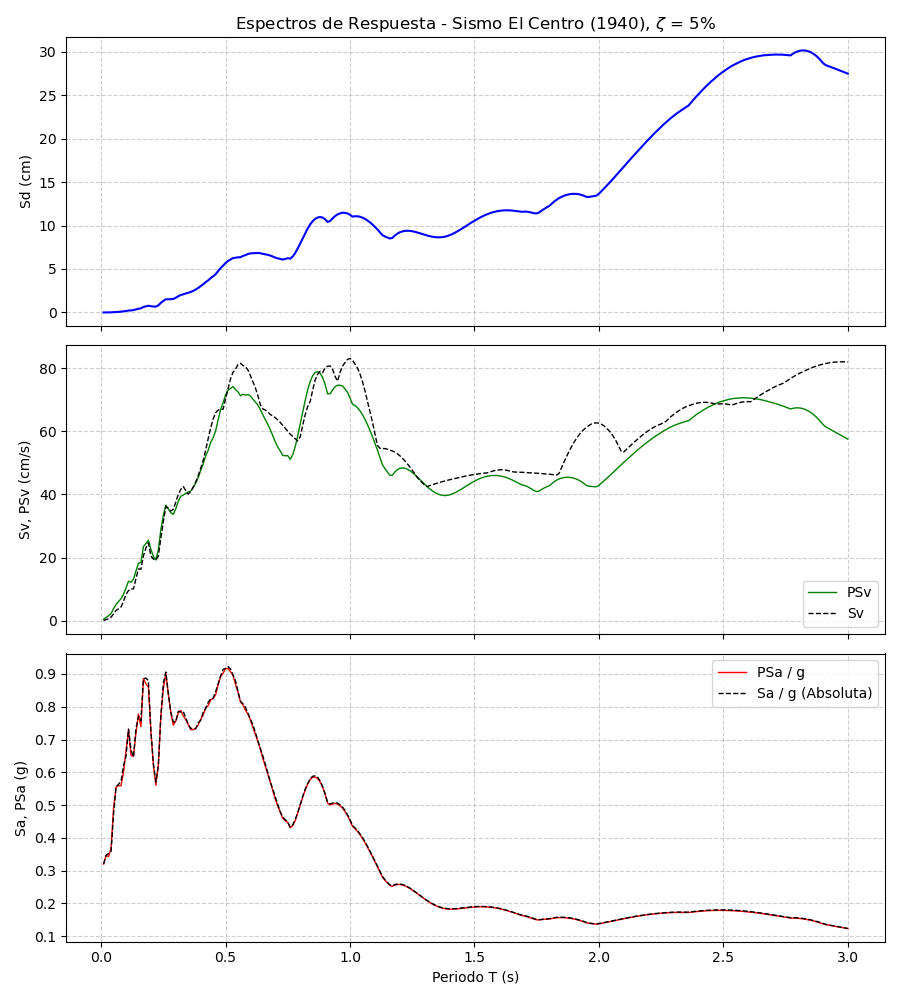

In [16]:
fig, axs = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

# 1. Espectro de Desplazamiento Sd
axs[0].plot(periodos, Sd, color="blue", lw=1.5)
axs[0].set_ylabel("Sd (cm)")
axs[0].set_title(f"Espectros de Respuesta - Sismo El Centro (1940), $\zeta$ = {ZETA*100:.0f}%")
axs[0].grid(True, linestyle='--', alpha=0.6)

# 2. Espectro Velocidad Sv y Pseudo-Velocidad PSv
axs[1].plot(periodos, PSv, color="green", lw=1.0, label='PSv')
axs[1].plot(periodos, Sv,  color="black", lw=1.0, linestyle='--', label='Sv')
axs[1].set_ylabel("Sv, PSv (cm/s)")
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend(loc="lower right")

# 3. Espectro Pseudo-Aceleración PSa (Y Aceleración Absoluta ajustada con 'g')
# La pseudo-aceleracion aprox coincide con la aceleración absoluta (Sa) en sistemas con bajo amortiguamiento
axs[2].plot(periodos, PSa/g, color="red",   lw=1.0, label='PSa / g')
axs[2].plot(periodos, Sa/g,  color="black", lw=1.0, linestyle='--', label='Sa / g (Absoluta)')
axs[2].set_xlabel("Periodo T (s)")
axs[2].set_ylabel("Sa, PSa (g)")
axs[2].grid(True, linestyle='--', alpha=0.6)
axs[2].legend()

plt.tight_layout()
plt.show()

## 7. Dibujo del espectro de respuesta 3D (waterfall)

La forma más intuitiva de entender cómo se obtiene un espectro de respuesta es mediante un diagrama tridimensional (*waterfall plot*). La siguiente función ilustra la aceleración del terreno y superpone las respuestas calculadas de osciladores con diferentes periodos para luego conformar la curva de la aceleración espectral $S_a(T)$.

In [17]:
def plot_espectro_waterfall(periodos_finos, magnitud_espectro, tipo_espectro, titulo_z, t_sismo, ag, ZETA, nombre_sismo, anio_sismo):
    """
    Genera una gráfica 3D tipo "waterfall" (cascada) que ilustra cómo
    se construye un espectro de respuesta a partir de un acelerograma real.
    """
    # Periodos "representativos" que se muestran como historias individuales
    #| en la gráfica de cascada (waterfall)
    periodos_waterfall = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8]
    colores = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#e377c2"]

    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Curva envolvente del espectro de respuesta (al fondo, t≈0)
    t_fondo = np.full_like(periodos_finos, tmax_sismo)  # se dibuja pegada al fondo

    ax.plot(periodos_finos, t_fondo, magnitud_espectro, color="black", lw=1.8, label=f"Espectro de respuesta (ζ={ZETA*100:.0f}%)")

    # Historia del sismo (T -> 0, al fondo del eje periodo), solo en el espectro de aceleración (Sa)
    if tipo_espectro == "Sa":
        ax.plot(np.zeros_like(t_sismo), t_sismo, ag/g, color="black", lw=0.6,
            label=f"Sismo {nombre_sismo} ({anio_sismo})")

    # inicializamos el mínimo global de la magnitud que estamos calculando
    # (el valor más pequeño que se ha encontrado en todas las historias)
    z_min_global = np.inf

    # Historias de respuesta para cada periodo seleccionado
    picos_waterfall = []   # guarda (T, t_del_pico, valor_pico) para las líneas guía
    for T, color in zip(periodos_waterfall, colores):
        u, v, _, a_abs = respuesta_1gdl_newmark(ag, dt, T, ZETA)

        match tipo_espectro:
            case "Sd":
                historia_respuesta = u
            case "Sv":
                historia_respuesta = v
            case "Sa":
                historia_respuesta = a_abs/g
            case _:
                raise ValueError("tipo_espectro debe ser 'Sd', 'Sv' o 'Sa'.")
        
        # Actualizar el mínimo global de la magnitud que estamos calculando
        z_min_global = min(z_min_global, np.min(historia_respuesta))
            
        ax.plot(np.full_like(t_sismo, T), t_sismo, historia_respuesta, color=color, lw=0.6)
        
        idx_pico = np.argmax(np.abs(historia_respuesta))
        picos_waterfall.append((T, t_sismo[idx_pico], historia_respuesta[idx_pico]))
        
        # Etiqueta T=... a un lado del pico de cada traza
        ax.text(T, tmax_sismo, 0, f"T={T}s", color=color, fontsize=8)

    # Líneas guía punteadas: del pico de cada historia al espectro
    for T, t_pico, valor_pico in picos_waterfall:
        idx = np.argmin(np.abs(periodos_finos - T))
        valor_espectro = magnitud_espectro[idx]
        # Línea punteada negra que conecta el pico (T, t_pico, valor_pico)
        ax.plot([T, T], [t_pico, tmax_sismo], [valor_pico, valor_espectro], color="black", lw=0.7, linestyle='--')
        # con el punto correspondiente sobre la envolvente (T, 0, valor_espectro)
        ax.scatter([T, T], [t_pico, tmax_sismo], [valor_pico, valor_espectro], color="black", s=15, depthshade=False)

    # Formato de ejes y etiquetas
    ax.set_xlabel("Periodo T (s)", labelpad=10)
    ax.set_ylabel("Tiempo (s)", labelpad=10)
    ax.set_zlabel(titulo_z, labelpad=10)
    ax.set_title(f"Construcción del espectro de respuesta {tipo_espectro}\n"
                 f"Sismo {nombre_sismo} ({anio_sismo}) - ζ = {ZETA*100:.0f}%", fontsize=12)

    ax.set_xlim(0, Tmax)
    ax.set_ylim(0, tmax_sismo)
    
    # Ajuste de la escala en el eje Z 
    # Mínimo: el valor negativo más grande entre las respuestas.
    # Máximo: el valor máximo del espectro de respuesta.
    z_max_espectro = np.max(magnitud_espectro)
    ax.set_zlim(z_min_global * 1.05, z_max_espectro * 1.05)
    
    # Ajustar la relación de aspecto de la caja (X, Y, Z) para aprovechar mejor la altura
    try:
        ax.set_box_aspect((1.5, 3.0, 1.5))
    except AttributeError:
        pass
        
    ax.view_init(elev=18, azim=-61)   # ángulo de cámara similar a la referencia

    # Remueve el fondo de los ejes para que se vea más limpio
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    plt.tight_layout()
    plt.show()

Generando Waterfall para la Aceleración Absoluta, con el sismo de fondo


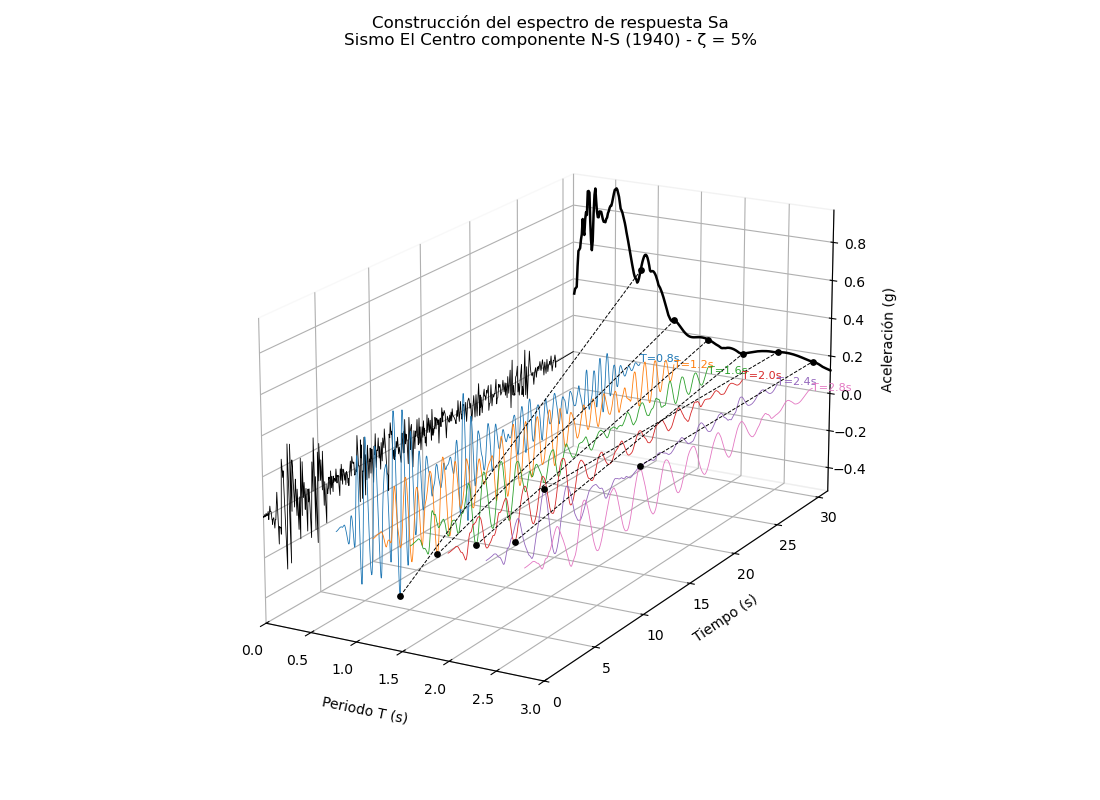

Generando Waterfall para la Velocidad


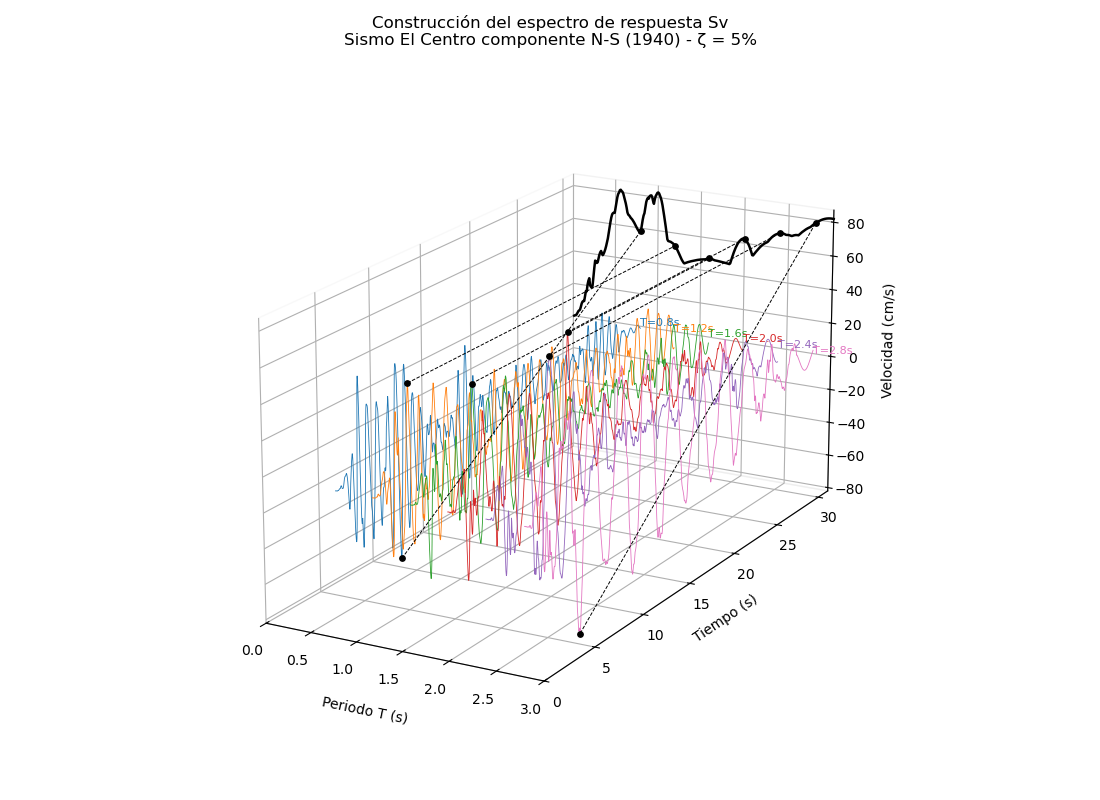

Generando Waterfall para el Desplazamiento


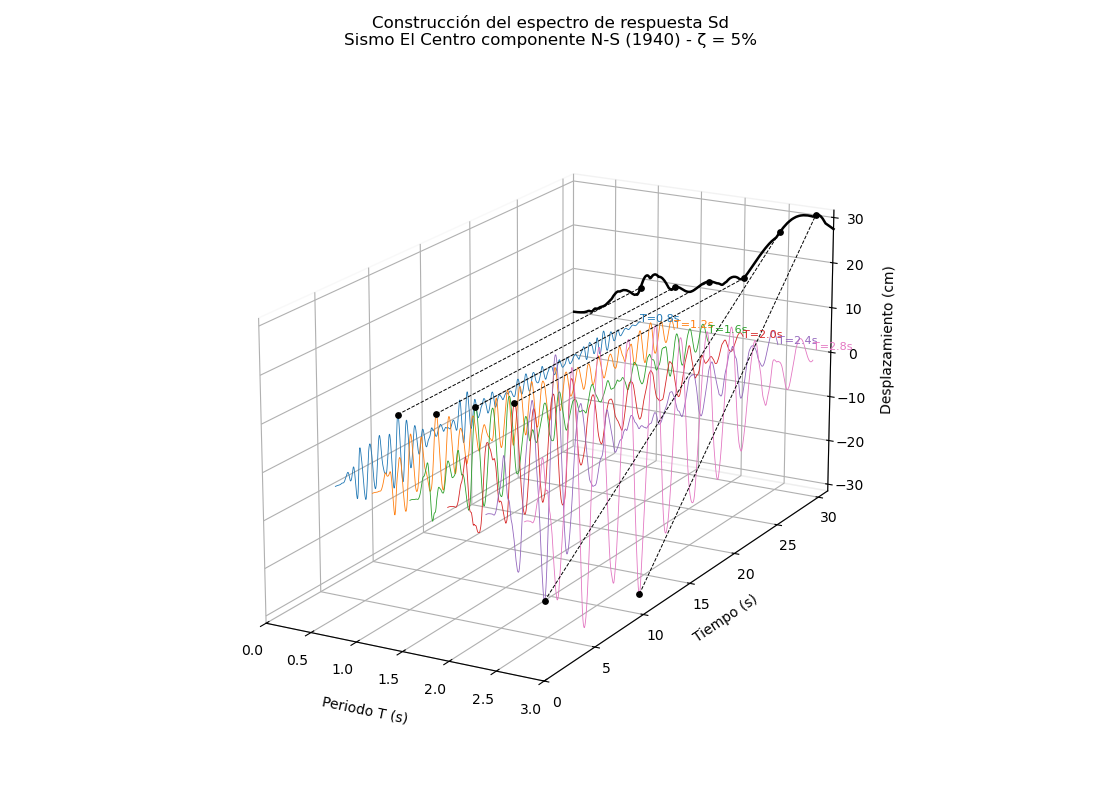

In [18]:
# Reutilizaremos los periodos y las magnitudes espectrales calculadas
periodos_finos = np.arange(0.01, Tmax + 0.01, 0.01)

# Construcción de la gráfica waterfall para los distintos espectros

# 1. ESPECTRO DE ACELERACIÓN ABSOLUTA Sa
print("Generando Waterfall para la Aceleración Absoluta, con el sismo de fondo")
plot_espectro_waterfall(
    periodos_finos, Sa/g,
    "Sa", "Aceleración (g)", 
    t_sismo, ag, ZETA, NOMBRE_SISMO, ANIO_SISMO
)

# 2. ESPECTRO DE VELOCIDAD Sv
print("Generando Waterfall para la Velocidad")
plot_espectro_waterfall(
    periodos_finos, Sv,
    "Sv", "Velocidad (cm/s)", 
    t_sismo, ag, ZETA, NOMBRE_SISMO, ANIO_SISMO
)

# 3. ESPECTRO DE DESPLAZAMIENTO Sd
print("Generando Waterfall para el Desplazamiento")
plot_espectro_waterfall(
    periodos_finos, Sd,
    "Sd", "Desplazamiento (cm)", 
    t_sismo, ag, ZETA, NOMBRE_SISMO, ANIO_SISMO
)